# Exploration

## Initializations

In [1]:
from pint import UnitRegistry
from process_engineering_toolkit.stream import Stream
from process_engineering_toolkit.reactors.pfr import PFR
import matplotlib.pyplot as plt

from process_engineering_toolkit.rate_laws import MassActionRateLaw
from process_engineering_toolkit.reactions import Reactions

## Stream definition

In [2]:
# # This will raise an error as mole fractions must be non-negative
# s1 = Stream("Fresh A", 10, {"A": -1, "B": 0.5}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

In [3]:
# # This will raise an error as compositions must sum to 1
# s1 = Stream("Fresh A", 10, {"A": 0.7, "B": 0.2}) 
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

# inlet = Flow([s1, s2])
# print(inlet.total_flows())

In [4]:
# s1 = Stream("Fresh A", 10, {"A": 0.8, "B": 0.2})
# s2 = Stream("Co-feed", 5, {"B": 0.6, "C": 0.4})

# print(s1.flows)
# print(s2.flows)

## Test case 1: PFR equilibrium conversion, single-reaction system

In [ ]:
# Define reaction
reactions = [
    {"equation": "A <-> 2B", "rate_law": "mass_action",   "parameters": {"kf": 0.3, "kb": 0.003}},
    ]

# Instantiate reactions object
my_reactions = Reactions(reactions)
print("### Reactions Class ###")
print(f"my_reactions.reactions[0].stoichiometry: {my_reactions.reactions[0].stoichiometry}")
print(f"Species: {my_reactions.species}")
print(f"Stoichiometric Matrix: {my_reactions.SM}")

# Define inlet stream
feed = Stream(name = "feed", total_flow = 20, composition = {"A": 0.6, "I": 0.4})
flows = feed.flows
print("### Stream Class ###")
print(flows)

# Define parameters for PFR reactor
parameters = {
    "phase": "gas",  # or "liquid"
    "operation": "constant_pressure",  # or "constant_density"
    "T": 340,
    "P": 2*101325
}

pfr = PFR(my_reactions, inlet_streams = [feed], parameters = parameters)
print("### PFR Class ###")
print(f"Species: {pfr.species}")
print(f"SM: {pfr.SM}")
print(f"Inlet vector: {pfr.build_inlet_vector()}")

Xeq = pfr.equilibrium_conversion("A")
print("Equilibrium conversion:", Xeq)

### Reactions Class ###
my_reactions.reactions[0].stoichiometry: {'A': -1, 'B': 2}
Species: ['A', 'B']
Stoichiometric Matrix: [[-1.]
 [ 2.]]
### Stream Class ###
{'A': 12.0, 'I': 8.0}
### PFR Class ###
Species: ['A', 'B', 'I']
SM: [[-1.]
 [ 2.]
 [ 0.]]
Inlet vector: [12.  0.  8.]
Equilibrium conversion: 0.5759007764246823


## Test Case 2: PFR volume from target conversion, single-reaction system

Required PFR volume: 0.6316541154157828
Conversion at 5 m^3: 0.5759215841795504


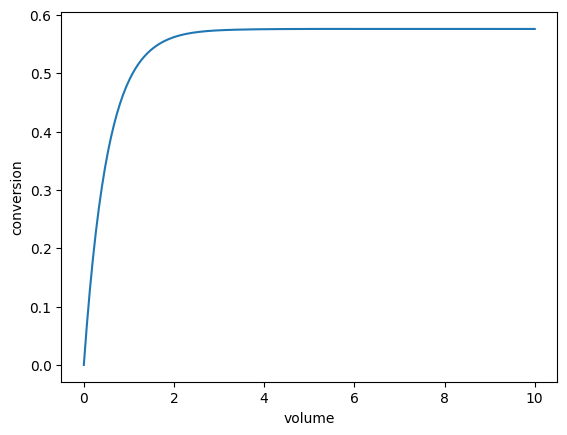

In [6]:
pfr.solve((0,10))
profile = pfr.profile("A", n_points = 300)
# profile["conversion"]
# profile["concentration"]["A"]
# profile["flows"]["B"]
# profile["mole_fraction"]["A"]
# profile["rate"]["R1"]

V_req = pfr.volume_for_conversion("A", 0.4)  # Find volume for 40% conversion
print("Required PFR volume:", V_req)

X = pfr.conversion_at_volume("A", 5)  # Find conversion at 5 m^3
print("Conversion at 5 m^3:", X)


# plt.plot(profile["conversion"], profile["concentration"]["B"])
plt.plot(profile["volume"], profile["conversion"])
plt.xlabel("volume")
plt.ylabel("conversion")
plt.show()


## Mass Action vs Power Law testing

### Setup

In [1]:
import numpy as np
from process_engineering_toolkit.rate_laws import MassActionRateLaw, PowerLawRateLaw

# Species
species_list = ["A", "B", "C"]

# Stoichiometry
stoichiometry = {
    "A": -1,
    "B": -1,
    "C": 1
}

# Concentrations (mol/L)
C = np.array([2.0, 1.5, 0.0])
T = 350  # K


### Rate determination: Irreversibel reaction

In [2]:
# Mass Action (elementary reaction)
params_mass_action = {
    "kf": 0.5
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action rate:", ma.rate(C, T))

Mass action rate: 1.5


In [3]:
# Power Law
params_power_law = {
    "expression": "A * B",
    "kf": 0.5
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law rate:", pl.rate(C, T))

Power law rate: 1.5


### Rate determination: Reversible reaction

In [4]:
C = np.array([2.0, 1.5, 0.5])
T = 350

In [5]:
# Mass Action
params_mass_action = {
    "kf": 0.5,
    "kb": 0.1
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action reversible rate:", ma.rate(C, T))

Mass action reversible rate: 1.45


In [6]:
# Power Law
params_power_law = {
    "expression": "A * B - C",
    "kf": 0.5,
    "kb": 0.1
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law reversible rate:", pl.rate(C, T))

Power law reversible rate: 1.45


### Non-integer orders (Power Law only)

In [7]:
params_power_law = {
    "expression": "A^0.5 * B^1.2",
    "kf": 0.5
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law fractional rate:", pl.rate(C, T))

Power law fractional rate: 1.150256015128918


In [8]:
print(0.5*C[0]**(0.5)*C[1]**(1.2))

1.150256015128918


### Arrhenius test

In [9]:
params_mass_action = {
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

ma = MassActionRateLaw(stoichiometry, species_list, **params_mass_action)

print("Mass action Arrhenius rate:", ma.rate(C, T))

Mass action Arrhenius rate: 0.00010345710371226898


In [10]:
for T in [300, 350, 400]:
    print(T, ma.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


In [11]:
params_power_law = {
    "expression": "A * B",
    "k0_f": 1e3,
    "Ea_f": 50000  # J/mol
}

pl = PowerLawRateLaw(stoichiometry, species_list, **params_power_law)

print("Power law Arrhenius rate:", pl.rate(C, 350))

Power law Arrhenius rate: 0.00010345710371226898


In [12]:
for T in [300, 350, 400]:
    print(T, pl.rate(C, T))

300 5.902465985837268e-06
350 0.00010345710371226898
400 0.0008862483374188033


### Edge cases: Invalid usage

In [13]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * B",
    kb=0.1  # ← should trigger validation
)

ValueError: Backward rate constants provided but expression has no backward term

In [14]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="A * D",  # D not in species_list
    kf=1.0
)

ValueError: Unknown species in rate expression: D

In [23]:
PowerLawRateLaw(
    stoichiometry,
    species_list,
    expression="a**(1/2) * B",  # Invalid math symbol (for simplicity, division symbol not allowed)
    kf=1.0
)

ValueError: Invalid exponent in factor a^(1/2)